# Comparison + Real-World Meaning

Numerical Estimation of River Cross-Sectional Area — Final Comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Results from Person 2 and Person 3

Both methods were applied to the **same** river cross-section dataset (11 depth measurements, 2 m apart across a 20 m wide channel), so the two area estimates can be compared directly.

In [ ]:
# Results carried over from the group's earlier notebooks
trapezoidal_area = 43.7000   # Trapezoidal Rule
simpsons_area = 43.5333      # Simpson's 1/3 Rule

print(f"Trapezoidal Rule area:  {trapezoidal_area:.4f} m\u00b2")
print(f"Simpson's 1/3 Rule area: {simpsons_area:.4f} m\u00b2")

Trapezoidal Rule area:  43.7000 m²
Simpson's 1/3 Rule area: 43.5333 m²


## 2. Comparison table

Putting both estimates side by side, along with the absolute and percentage difference between them.

In [3]:
abs_diff = abs(trapezoidal_area - simpsons_area)
pct_diff = (abs_diff / simpsons_area) * 100

comparison = pd.DataFrame({
    "Method": ["Trapezoidal Rule", "Simpson's 1/3 Rule"],
    "Estimated Area (m\u00b2)": [trapezoidal_area, simpsons_area]
})

print(comparison.to_string(index=False))
print(f"\nAbsolute difference: {abs_diff:.4f} m\u00b2")
print(f"Percentage difference: {pct_diff:.2f}%")

            Method  Estimated Area (m²)
  Trapezoidal Rule              43.7000
Simpson's 1/3 Rule              43.5333

Absolute difference: 0.1667 m²
Percentage difference: 0.38%


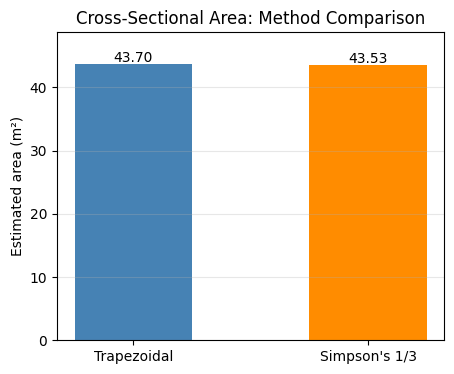

In [4]:
# Quick visual comparison
plt.figure(figsize=(5, 4))
methods = ["Trapezoidal", "Simpson's 1/3"]
areas = [trapezoidal_area, simpsons_area]
bars = plt.bar(methods, areas, color=["steelblue", "darkorange"], width=0.5)
plt.ylabel("Estimated area (m\u00b2)")
plt.title("Cross-Sectional Area: Method Comparison")
plt.ylim(0, max(areas) + 5)

for bar, area in zip(bars, areas):
    plt.text(bar.get_x() + bar.get_width()/2, area + 0.3, f"{area:.2f}", ha="center")

plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 3. What the difference tells us

The two methods agree to within about **0.4%**, which is a very small gap. That closeness is informative:

- **Trapezoidal Rule** approximates the profile with straight line segments between consecutive points. For a perfectly smooth, dome-shaped profile this would typically *underestimate* the true area (the chord sits below the curve). Our depth data isn't perfectly smooth, though — it flattens and dips slightly around the 6-10 m mark — so the curvature effect isn't one-directional. In this dataset, the Trapezoidal Rule actually comes out slightly *higher* than Simpson's Rule (43.70 m² vs 43.53 m², a difference of 0.17 m²).
- **Simpson's 1/3 Rule** fits a smooth parabola through each group of three points, so it captures local curvature more faithfully and is generally treated as the more reliable of the two for a profile like this.

Because the two results are so close (well under 1%), it suggests the 11 measurement points were already dense enough to describe the shape of the riverbed well — the straight-line approximation isn't losing much information. If the two methods had produced very different areas, that would be a signal that the profile is changing sharply between measurement points and that **more data points** are needed for either method to be trusted.

## 4. Real-world application

Cross-sectional area isn't just a geometry exercise — it feeds directly into practical river engineering:

- **Discharge (flow rate):** Discharge $Q = A \times v$, where $A$ is the cross-sectional area and $v$ is the average flow velocity. An error in $A$ propagates directly into an error in the estimated discharge, which is used for water resource planning, irrigation allocation, and hydropower design.
- **Flood risk assessment:** Engineers compare the channel's cross-sectional capacity against expected storm inflows to judge how much water a river can carry before it overflows its banks. Getting $A$ wrong in either direction skews that judgment — an underestimate makes the channel look safer than it is, while an overestimate (as happened with the Trapezoidal Rule here) risks overstating how much water the channel can actually carry.
- **Hydraulic structure design:** Bridges, culverts, and embankments are sized using cross-sectional area estimates like these, so choosing a numerically accurate integration method has real downstream consequences for cost and safety margins.

## 5. Summary

Starting from a single measured depth profile, the group estimated the river's cross-sectional area two different ways — the Trapezoidal Rule and Simpson's 1/3 Rule — and found results that agree to within about 0.4%. That agreement gives confidence in the estimate, and shows how a simple numerical integration technique connects directly to real decisions about discharge, flood risk, and hydraulic design.